**Project Overview**

This project addresses the task of sentiment analysis on Amazon product reviews, aiming to classify each review as positive or negative. The analysis compares classical natural language processing techniques with modern transformer-based models, using the same dataset and evaluation protocol to ensure a fair comparison.

# Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import os, re, random, math
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
!pip install gensim
from gensim.models import Word2Vec

In [ ]:
 !pip -q install -U pandas numpy scikit-learn gensim nltk tqdm matplotlib \
     "transformers>=4.40,<5" datasets tensorflow


In [ ]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [ ]:
from transformers import AutoTokenizer, TFDistilBertModel
import tensorflow as tf

In [ ]:
import gensim.downloader as api

In [ ]:
!pip install -U pyarrow datasets

from datasets import Dataset
from transformers import TFDistilBertForSequenceClassification, DataCollatorWithPadding

In [ ]:
!pip install wordcloud

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Load Data and Preprocessing

In [ ]:
path = '/content/drive/MyDrive/Amazon_Unlocked_Mobile.csv'
df = pd.read_csv(path)

The dataset consists of Amazon Unlocked Mobile reviews. Reviews with a rating equal to 3 are removed, as they represent neutral sentiment. The remaining reviews are mapped to a binary label:


*   Ratings greater than 3 are labeled as positive
*   Ratings lower than 3 are labeled as negative

To improve computational efficiency while preserving class balance, a stratified 30% subset of the dataset is used. Missing values in the review text and ratings are removed.

In [ ]:
df = df[df["Rating"] != 3].copy()
df = df.dropna(subset=["Reviews", "Rating"]).copy()
df["Positively Rated"] = np.where(df["Rating"] > 3, 1, 0)
df["label"] = (df["Rating"] > 3).astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 382007 entries, 0 to 413839
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Product Name      382007 non-null  object 
 1   Brand Name        321311 non-null  object 
 2   Price             376673 non-null  float64
 3   Rating            382007 non-null  int64  
 4   Reviews           382007 non-null  object 
 5   Review Votes      370668 non-null  float64
 6   Positively Rated  382007 non-null  int64  
 7   label             382007 non-null  int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 26.2+ MB


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 382007 entries, 0 to 413839
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Product Name      382007 non-null  object 
 1   Brand Name        321311 non-null  object 
 2   Price             376673 non-null  float64
 3   Rating            382007 non-null  int64  
 4   Reviews           382007 non-null  object 
 5   Review Votes      370668 non-null  float64
 6   Positively Rated  382007 non-null  int64  
 7   label             382007 non-null  int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 26.2+ MB


Using a smaller number of entries for faster computation while maintaining positive/negative ratio.

In [ ]:
PERCENT = 0.3

df_small, _ = train_test_split(
    df,
    train_size=PERCENT,
    stratify=df["label"]
)

df = df_small

In [ ]:
df.head(10)

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes,Positively Rated,label
223791,"LG G4 H815 Factory Unlocked Cellphone, Interna...",LG,351.09,2,Phone does not work as advertised. Does not wo...,1.0,0,0
13957,Apple iPhone 4S 32GB (Black) Unlocked - Verizon,Apple,199.00,5,Great product and fast shipping. Thank you.,0.0,1,1
411617,"ZTE Axon - Factory Unlocked Phone, 32 GB Chrom...",ZTE,249.98,5,I'm a phone guy. I have 6 phones and this is c...,2.0,1,1
44014,Apple iPhone 5s 32GB (Gold) - Verizon Wireless,Apple,125.00,4,"Battery life seems to be no so great, but over...",0.0,1,1
202829,Huawei P8 Lite US Version- 5 Unlocked Android ...,Huawei,198.99,5,"love this.dual sim card,long battery and ...",0.0,1,1
45040,Apple iPhone 5s 32GB (Silver) - AT&T,Apple,43.95,5,My 13 year old daughter selected the phone and...,NaN,1,1
12516,Apple iPhone 4S 16GB 3G WiFi White Smartphone ...,NaN,74.95,5,EXCELENTE VENDEDOR REALIZARE MAS COMPRAS EN EL...,0.0,1,1
324917,Samsung Galaxy Note 3 N9005 Unlocked Cellphone...,Samsung,325.16,4,Nice phone,0.0,1,1
109339,BLU Dash J Unlocked Phone - Retail Packaging -...,BLU,39.99,5,I liked,1.0,1,1
87203,BlackBerry 9720 Samoa Black Factory Unlocked O...,NaN,339.99,5,excellent,0.0,1,1


Metrics

In [ ]:
def show_results(name, y_true, y_pred):
    print(f"\n=== {name} ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("F1:", f1_score(y_true, y_pred))
    print(classification_report(y_true, y_pred, digits=4))

results = []

def store_result(name, y_true, y_pred):
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred)
    })

Cleaning Functions

Two separate preprocessing pipelines are applied, depending on the model family:

Classical Models (Word2Vec, GloVe)

*   Lowercasing
*   Removal of URLs and special characters
*  Tokenization
*   Stopword removal
*   Stemming


This preprocessing reduces noise and improves the quality of averaged word embeddings.

Transformer-Based Models (BERT)

*   Minimal preprocessing
*   Lowercasing and removal of URLs only


Stopwords and word structure are preserved, as BERT relies on contextual and syntactic information.

In [ ]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words("english"))

def clean_text(s):
    s = str(s).lower()
    s = re.sub(r"http\S+|www\.\S+", " ", s)
    s = re.sub(r"[^a-z0-9\s']", " ", s)
    s = re.sub(r"\s+", " ",s).strip()
    s = re.sub(r'#', '', s)
    words = s.split()
    processed_words = [stemmer.stem(word) for word in words if word not in stop_words]

    return processed_words

def clean_text_bert(s):
    s = str(s).lower()
    s = re.sub(r"http\S+|www\.\S+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    s = re.sub(r'#', '', s)
    return s

In [ ]:
processed_reviews = df["Reviews"].apply(clean_text)

In [ ]:
processed_reviews

,Reviews
223791,"[phone, work, advertis, work, 4g, network, mobil]"
13957,"[great, product, fast, ship, thank]"
411617,"[phone, guy, 6, phone, current, daili, driver,..."
44014,"[batteri, life, seem, great, overal, happi]"
202829,"[love, dual, sim, card, long, batteri]"
...,...
144070,"[overheat, shut, frequent, one, issu, need, re..."
84885,"[product, receiv, hope, new, unlock, intern, u..."
273626,"[great, phone, great, price, bought, son', bir..."
208744,"[read, instruct, band, work, suck, poor, sign,..."


In [ ]:
df["tokens"] = processed_reviews   # W2V/GloVe
df["bert_text"] = df["Reviews"].apply(clean_text_bert)  # BERT

Train / Validation / Test Split


The dataset is split into training, validation, and test sets using stratified sampling to maintain the class distribution across all splits.
The same split is used for all models.

For Word2Vec and GloVe, empty reviews produced after preprocessing are removed from all splits to avoid invalid input. Separate label arrays are maintained to prevent misalignment between token-based and BERT-based models.

In [ ]:
# 1) Train+Val / Test
trainval_df, test_df = train_test_split(
    df,
    test_size=0.25,
    stratify=df["label"]
)

# 2) Train / Validation
train_df, val_df = train_test_split(
    trainval_df,
    test_size=0.2,          # 20% του trainval => 15% συνολικά
    stratify=trainval_df["label"]
)

# Tokens (Word2Vec / GloVe)
Xtok_train = train_df["tokens"].tolist()
Xtok_val   = val_df["tokens"].tolist()
Xtok_test  = test_df["tokens"].tolist()

# Text (BERT)
Xbert_train = train_df["bert_text"].tolist()
Xbert_val   = val_df["bert_text"].tolist()
Xbert_test  = test_df["bert_text"].tolist()

# Labels
y_train = train_df["label"].values
y_val   = val_df["label"].values
y_test  = test_df["label"].values

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 45840
Val: 11460
Test: 19101


In [ ]:
# --- Keep separate labels for token models vs BERT models ---
y_tok_train = y_train.copy()
y_tok_val   = y_val.copy()
y_tok_test  = y_test.copy()

y_bert_train = y_train.copy()
y_bert_val   = y_val.copy()
y_bert_test  = y_test.copy()

In [ ]:
len(Xtok_train)

45840

Filter out empty reviews (after preprocessing)


In [ ]:
def filter_empty_token_reviews(Xtok, y):
    mask = np.array([len(t) > 0 for t in Xtok])
    Xtok_f = [t for t, m in zip(Xtok, mask) if m]
    y_f = y[mask]
    return Xtok_f, y_f

# Filter TRAIN/VAL/TEST for W2V/GloVe (only tokens + labels)
Xtok_train, y_tok_train = filter_empty_token_reviews(Xtok_train, y_tok_train)
Xtok_val,   y_tok_val   = filter_empty_token_reviews(Xtok_val,   y_tok_val)
Xtok_test,  y_tok_test  = filter_empty_token_reviews(Xtok_test,  y_tok_test)

print("After filtering:")
print("Train:", len(Xtok_train), len(y_tok_train))
print("Val:",   len(Xtok_val),   len(y_tok_val))
print("Test:",  len(Xtok_test),  len(y_tok_test))

After filtering:
Train: 45711 45711
Val: 11417 11417
Test: 19046 19046


# Word2Vec

Word2Vec embeddings are trained on the tokenized training reviews. Each review is converted into a single fixed-length vector by averaging the Word2Vec embeddings of all its words and these vectors are stacked to form the input matrix for the classifier, producing a fixed-length numerical representation. A Logistic Regression classifier is then trained on these vectors.

In [ ]:
EMBED_DIM = 100

In [ ]:
w2v = Word2Vec(
    sentences=Xtok_train,
    vector_size=EMBED_DIM,
    window=5,
    min_count=2,
    workers=os.cpu_count() or 2
)

In [ ]:
def review_to_vector(word_list, word2vec_model, embedding_dim):
    word_vectors = [
        word2vec_model.wv[word]
        for word in word_list
        if word in word2vec_model.wv
    ]

    if len(word_vectors) == 0:
        return np.zeros(embedding_dim)

    return np.mean(word_vectors, axis=0)

train_vectors = np.vstack([review_to_vector(r, w2v, 100) for r in Xtok_train])
test_vectors  = np.vstack([review_to_vector(r, w2v, 100) for r in Xtok_test])

print("train_vectors:", train_vectors.shape)
print("test_vectors:", test_vectors.shape)
print("y_train:", len(y_tok_train))
print("y_test:", len(y_tok_test))

# Train classifier
model = LogisticRegression(max_iter=2000)
model.fit(train_vectors, y_tok_train)

# Predict
test_predictions = model.predict(test_vectors)

train_vectors: (45711, 100)
test_vectors: (19046, 100)
y_train: 45711
y_test: 19046


In [ ]:
show_results("(a) Word2Vec + Logistic Regression (TEST)", y_tok_test, test_predictions)
store_result("Word2Vec + LR", y_tok_test, test_predictions)


=== (a) Word2Vec + Logistic Regression (TEST) ===
Accuracy: 0.9025517168959362
F1: 0.9356761627503986
              precision    recall  f1-score   support

           0     0.8402    0.7618    0.7991      4845
           1     0.9212    0.9506    0.9357     14201

    accuracy                         0.9026     19046
   macro avg     0.8807    0.8562    0.8674     19046
weighted avg     0.9006    0.9026    0.9009     19046



# Glove + Logistic Regression

In [ ]:
def glove_review_to_vector(word_list, model, embedding_dim):
    word_vectors = [
        model[word]
        for word in word_list
        if word in model
    ]

    if len(word_vectors) == 0:
        return np.zeros(embedding_dim)

    return np.mean(word_vectors, axis=0)

glove = api.load("glove-wiki-gigaword-100")
GLOVE_DIM = glove.vector_size

Xtr_glove = np.vstack([glove_review_to_vector(r, glove, GLOVE_DIM) for r in Xtok_train])
Xte_glove = np.vstack([glove_review_to_vector(r, glove, GLOVE_DIM) for r in Xtok_test])

glove_lr = LogisticRegression(max_iter=2000)
glove_lr.fit(Xtr_glove, y_tok_train)
pred_glove = glove_lr.predict(Xte_glove)

show_results("(b) GloVe + Logistic Regression (TEST)", y_tok_test, pred_glove)
store_result("GloVe + LR", y_tok_test, pred_glove)


=== (b) GloVe + Logistic Regression (TEST) ===
Accuracy: 0.8548776646014912
F1: 0.9056204329713856
              precision    recall  f1-score   support

           0     0.7627    0.6235    0.6861      4845
           1     0.8791    0.9338    0.9056     14201

    accuracy                         0.8549     19046
   macro avg     0.8209    0.7787    0.7959     19046
weighted avg     0.8495    0.8549    0.8498     19046



# BERT embeddings + Logistic Regression (TensorFlow)


In this approach, DistilBERT is used as a frozen feature extractor. Each review is passed through the BERT encoder, and the representation of the first token is used as a sentence-level embedding. These embeddings are then classified using Logistic Regression.

In [ ]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

bert_encoder = TFDistilBertModel.from_pretrained(
    MODEL_NAME,
    from_pt=True,
    use_safetensors=False
)
bert_encoder.trainable = False

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_transform.weight', 'vocab_projector.bias', 'vocab_layer_norm.bias', 'vocab_transform.bias', 'vocab_projector.weight', 'vocab_layer_norm.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


In [ ]:
from tqdm.notebook import tqdm

def cls_embeddings_tf_batched(texts, tokenizer, model, batch_size=32, max_length=128):
    embeddings = []
    # Processing per batches for speed
    for i in tqdm(range(0, len(texts), batch_size), desc="Processing batches"):
        batch_texts = texts[i : i + batch_size]

        # Tokenization
        tokens = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            return_tensors="tf",
            max_length=max_length
        )

        # Inference
        outputs = model(**tokens, training=False)
        cls_vectors = outputs.last_hidden_state[:, 0, :]
        embeddings.append(cls_vectors.numpy())

    if embeddings:
        return np.vstack(embeddings)
    else:
        return np.array([])



In [ ]:
print(len(Xbert_train), len(y_bert_train))

45840 45840


In [ ]:
# Export embeddings
# If OOM (Out Of Memory) then reduce batch_size
Xtr_bert = cls_embeddings_tf_batched(Xbert_train, tokenizer, bert_encoder, batch_size=32)
Xte_bert = cls_embeddings_tf_batched(texts=Xbert_test, tokenizer=tokenizer, model=bert_encoder, batch_size=32)
print(Xtr_bert.shape[0], len(y_bert_train))
#  Logistic Regression
bert_lr = LogisticRegression(max_iter=3000, C=0.5)
bert_lr.fit(Xtr_bert, y_bert_train)
pred_bert = bert_lr.predict(Xte_bert)

Processing batches:   0%|          | 0/1433 [00:00<?, ?it/s]

Processing batches:   0%|          | 0/597 [00:00<?, ?it/s]

45840 45840


In [ ]:
show_results("(c) BERT embeddings + Logistic Regression (TEST)", y_bert_test, pred_bert)
store_result("BERT emb + LR", y_bert_test, pred_bert)


=== (c) BERT embeddings + Logistic Regression (TEST) ===
Accuracy: 0.9303177844091932
F1: 0.9535832606800348
              precision    recall  f1-score   support

           0     0.8768    0.8444    0.8603      4853
           1     0.9477    0.9596    0.9536     14248

    accuracy                         0.9303     19101
   macro avg     0.9122    0.9020    0.9069     19101
weighted avg     0.9297    0.9303    0.9299     19101



# Bert fine-tuning

Finally, DistilBERT is fine-tuned end-to-end for sentiment classification by adding a classification head on top of the encoder. The model is trained for three epochs, with early stopping based on validation loss to reduce overfitting.

This approach represents the most expressive and computationally intensive model in the study.

In [ ]:
train_ds = Dataset.from_dict({"text": Xbert_train, "label": y_bert_train.tolist()})
val_ds   = Dataset.from_dict({"text": Xbert_val,   "label": y_bert_val.tolist()})
test_ds  = Dataset.from_dict({"text": Xbert_test,  "label": y_bert_test.tolist()})

def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True)

train_tok = train_ds.map(tokenize_batch, batched=True, remove_columns=["text"])
val_tok   = val_ds.map(tokenize_batch,   batched=True, remove_columns=["text"])
test_tok  = test_ds.map(tokenize_batch,  batched=True, remove_columns=["text"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="tf")

tf_train = train_tok.to_tf_dataset(
    columns=["input_ids", "attention_mask"],
    label_cols=["label"],
    shuffle=True,
    batch_size=16,
    collate_fn=data_collator,
)

tf_val = val_tok.to_tf_dataset(
    columns=["input_ids", "attention_mask"],
    label_cols=["label"],
    shuffle=False,
    batch_size=32,
    collate_fn=data_collator,)

tf_test = test_tok.to_tf_dataset(
    columns=["input_ids", "attention_mask"],
    label_cols=["label"],
    shuffle=False,
    batch_size=32,
    collate_fn=data_collator,)

ft_model = TFDistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    from_pt=True,
    use_safetensors=False
)



Map:   0%|          | 0/45840 [00:00<?, ? examples/s]

Map:   0%|          | 0/11460 [00:00<?, ? examples/s]

Map:   0%|          | 0/19101 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/datasets/arrow_dataset.py:405: FutureWarning: The output of `to_tf_dataset` will change when a passing single element list for `labels` or `columns` in the next datasets version. To return a tuple structure rather than dict, pass a single string.
Old behaviour: columns=['a'], labels=['labels'] -> (tf.Tensor, tf.Tensor)  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor)  
New behaviour: columns=['a'],labels=['labels'] -> ({'a': tf.Tensor}, {'labels': tf.Tensor})  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor) 
  warnings.warn(
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_transform.weight', 'vocab_projector.bias', 'vocab_layer_norm.bias', 'vocab_transform.bias', 'vocab_projector.weight', 'vocab_layer_norm.weight']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model traine

The model was fine-tuned for three epochs, with validation monitoring to limit overfitting.

In [ ]:
ft_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy("accuracy")])

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=1,
    restore_best_weights=True)

ft_model.fit(tf_train, validation_data=tf_val, epochs=3, callbacks=[early_stop])

pred = ft_model.predict(tf_test)
pred_bert_ft = np.argmax(pred.logits, axis=1)

Epoch 1/3
2865/2865 [==============================] - 1448s 493ms/step - loss: 0.1362 - accuracy: 0.9492 - val_loss: 0.1173 - val_accuracy: 0.9567
Epoch 2/3
2865/2865 [==============================] - 1337s 467ms/step - loss: 0.0737 - accuracy: 0.9751 - val_loss: 0.1030 - val_accuracy: 0.9675
Epoch 3/3
597/597 [==============================] - 243s 404ms/step


In [ ]:
show_results("(d) BERT fine-tuning (TEST)", y_bert_test, pred_bert_ft)
store_result("BERT fine-tune", y_bert_test, pred_bert_ft)



=== (d) BERT fine-tuning (TEST) ===
Accuracy: 0.965970368043558
F1: 0.9772217549761705
              precision    recall  f1-score   support

           0     0.9366    0.9289    0.9328      4853
           1     0.9759    0.9786    0.9772     14248

    accuracy                         0.9660     19101
   macro avg     0.9562    0.9538    0.9550     19101
weighted avg     0.9659    0.9660    0.9659     19101



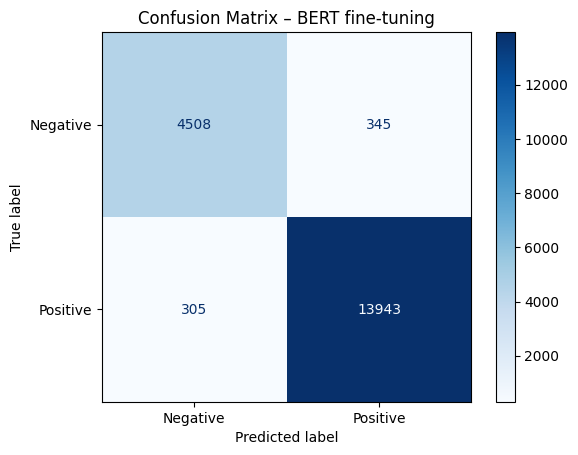

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_bert_test,
    pred_bert_ft,
    display_labels=["Negative", "Positive"],
    cmap="Blues"
)

plt.title("Confusion Matrix – BERT fine-tuning")
plt.show()

# Summary

Models are evaluated using Accuracy and F1-score.


In [ ]:
summary = pd.DataFrame(results).sort_values("f1", ascending=False)
print("\n=== SUMMARY (sorted by F1) ===")
print(summary)


=== SUMMARY (sorted by F1) ===
            model  accuracy        f1
5  BERT fine-tune  0.965970  0.977222
4   BERT emb + LR  0.930318  0.953583
0   Word2Vec + LR  0.903488  0.936231
2   Word2Vec + LR  0.902552  0.935676
1      GloVe + LR  0.855259  0.905944
3      GloVe + LR  0.854878  0.905620


for 30% of the data

=== SUMMARY (sorted by F1) ===
            

* model  accuracy        f1
*   3  BERT fine-tune  0.969675  0.979742
*   2   BERT emb + LR  0.936034  0.957317
*   0   Word2Vec + LR  0.906651  0.938388
* 1      GloVe + LR  0.856156  0.906788

The results confirm that transformer-based models outperform classical NLP approaches, with fine-tuned BERT providing the best trade-off between precision and recall on this dataset, even when trained on a reduced subset of the data.

# Example Reviews

In [ ]:
example_reviews = [
    "Amazing phone, great battery life and fast delivery!",
    "Terrible quality, the screen broke in two days.",
    "Good value for money, works well and looks nice.",
    "I wanted to love it, but the screen flickers sometimes and it's annoying.",
    "It’s okay for the price, but I wouldn’t recommend it to anyone.",
    "Sound is loud, yet the microphone is so bad people can’t hear me.",
    "After the update it became slower, but at least it looks nice.",
    "I’m not saying it’s terrible… I’m just saying I returned it the next day.",
    "This is the best phone I've ever bought (until it stopped turning on).",
    "Worst purchase ever, not working and customer support is bad.",
]

# ---------- Helper: label to text ----------
def to_sentiment(pred):
    return "POSITIVE" if int(pred) == 1 else "NEGATIVE"

# ============================================================
# (a) Word2Vec + Logistic Regression
# ============================================================
print("\n================ (a) Word2Vec + LR ================")
for text in example_reviews:
    tokens = clean_text(text)  # returns list of tokens
    x = review_to_vector(tokens, w2v, 100).reshape(1, -1)
    pred = model.predict(x)[0]
    print(f"\nText: {text}\nPrediction: {to_sentiment(pred)}")

# ============================================================
# (b) GloVe + Logistic Regression
# ============================================================
print("\n================ (b) GloVe + LR ================")
for text in example_reviews:
    tokens = clean_text(text)
    x = glove_review_to_vector(tokens, glove, glove.vector_size).reshape(1, -1)
    pred = glove_lr.predict(x)[0]
    print(f"\nText: {text}\nPrediction: {to_sentiment(pred)}")

# ============================================================
# (c) BERT embeddings + Logistic Regression
# ============================================================
print("\n================ (c) BERT embeddings + LR ================")

def single_bert_embedding(text, max_length=128):
    # minimal cleaning for BERT
    text = clean_text_bert(text)
    tokens = tokenizer(text, truncation=True, padding=True, max_length=max_length, return_tensors="tf")
    outputs = bert_encoder(**tokens, training=False)
    cls_vec = outputs.last_hidden_state[:, 0, :].numpy()  # shape (1, hidden)
    return cls_vec

for text in example_reviews:
    x = single_bert_embedding(text)
    pred = bert_lr.predict(x)[0]
    print(f"\nText: {text}\nPrediction: {to_sentiment(pred)}")

# ============================================================
# (d) BERT fine-tuning (TF classifier)
# ============================================================
print("\n================ (d) BERT fine-tuning ================")

def finetuned_bert_predict(text, max_length=128):
    text = clean_text_bert(text)
    tokens = tokenizer(text, truncation=True, padding=True, max_length=max_length, return_tensors="tf")
    out = ft_model(**tokens, training=False)
    pred = int(np.argmax(out.logits.numpy(), axis=1)[0])
    return pred

for text in example_reviews:
    pred = finetuned_bert_predict(text)
    print(f"\nText: {text}\nPrediction: {to_sentiment(pred)}")


================ (a) Word2Vec + LR ================

Text: Amazing phone, great battery life and fast delivery!
Prediction: POSITIVE

Text: Terrible quality, the screen broke in two days.
Prediction: NEGATIVE

Text: Good value for money, works well and looks nice.
Prediction: POSITIVE

Text: I wanted to love it, but the screen flickers sometimes and it's annoying.
Prediction: NEGATIVE

Text: It’s okay for the price, but I wouldn’t recommend it to anyone.
Prediction: POSITIVE

Text: Sound is loud, yet the microphone is so bad people can’t hear me.
Prediction: NEGATIVE

Text: After the update it became slower, but at least it looks nice.
Prediction: POSITIVE

Text: I’m not saying it’s terrible… I’m just saying I returned it the next day.
Prediction: NEGATIVE

Text: This is the best phone I've ever bought (until it stopped turning on).
Prediction: NEGATIVE

Text: Worst purchase ever, not working and customer support is bad.
Prediction: NEGATIVE

================ (b) GloVe + LR ==========

(a) Word2Vec + Logistic Regression

The Word2Vec-based model correctly classifies clearly positive and clearly negative reviews. However, it shows limitations when handling mixed or subtle sentiment.

(b) GloVe + Logistic Regression

The GloVe-based model exhibits similar behavior to Word2Vec, but with slightly weaker performance on difficult cases.

(c) BERT Embeddings + Logistic Regression

Using BERT embeddings significantly improves performance on complex examples.

The model correctly handles:

*   Negation (“not saying it’s terrible…”)
*   Mixed sentiment (“I wanted to love it, but…”)


However, some nuanced cases remain challenging.

The fine-tuned BERT model provides the most consistent and accurate predictions across all examples.

Key improvements include:
* Correct handling of negation and contrastive clauses
* Better interpretation of overall sentence meaning rather than isolated phrases



# Exploratory Analysis

Class distribution


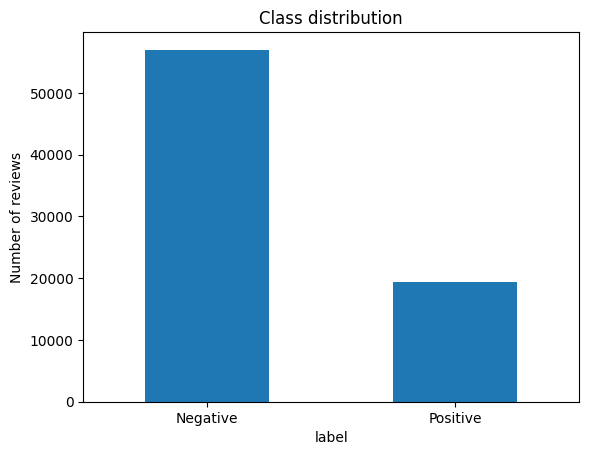

In [ ]:
label_counts = df["label"].value_counts()

plt.figure()
label_counts.plot(kind="bar")
plt.xticks([0,1], ["Negative", "Positive"], rotation=0)
plt.title("Class distribution")
plt.ylabel("Number of reviews")
plt.show()

Word2Vec Feature Importance

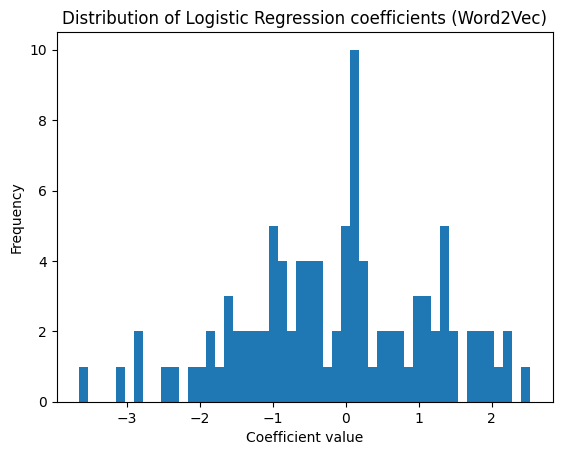

In [ ]:
# Logistic Regression feature importance

coefficients = model.coef_[0]

plt.figure()
plt.hist(coefficients, bins=50)
plt.title("Distribution of Logistic Regression coefficients (Word2Vec)")
plt.xlabel("Coefficient value")
plt.ylabel("Frequency")
plt.show()

Word clouds for positive and negative reviews.


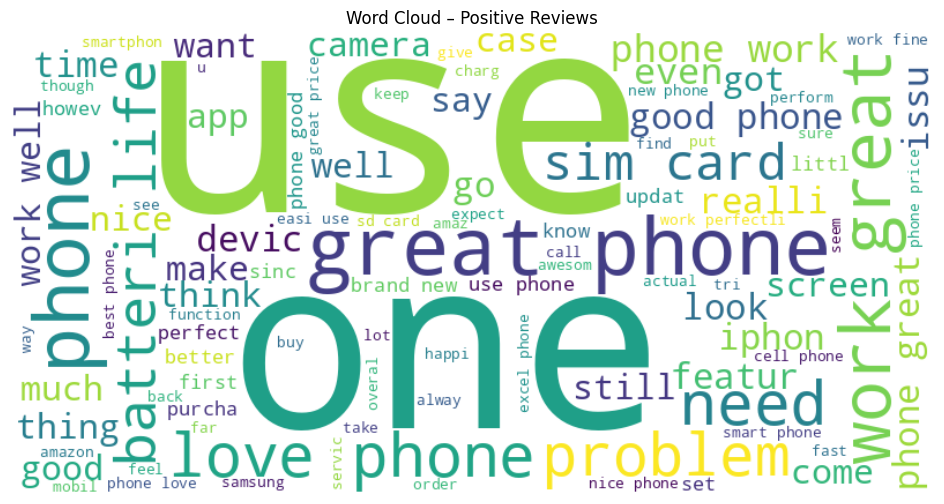

In [ ]:
from wordcloud import WordCloud
# ------------------------------------------------------------
# Select only POSITIVE reviews
# ------------------------------------------------------------
positive_reviews = df[df["label"] == 1]["tokens"]

# Flatten list of token lists into one list of words
positive_words = []
for review in positive_reviews:
    positive_words.extend(review)

# Convert list of words to a single string
positive_text = " ".join(positive_words)

# ------------------------------------------------------------
# Generate and display Word Cloud
# ------------------------------------------------------------
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100
).generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud – Positive Reviews")
plt.show()

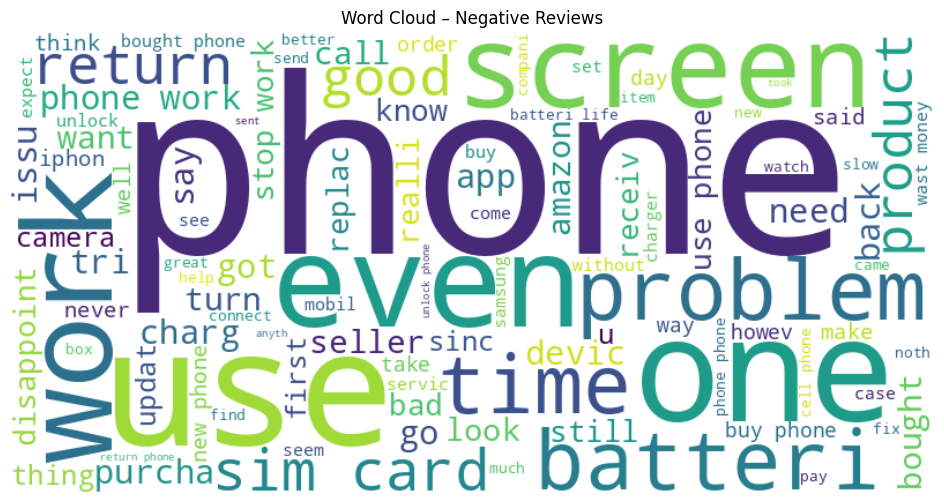

In [ ]:
# ------------------------------------------------------------
# Select only NEGATIVE reviews
# ------------------------------------------------------------
negative_reviews = df[df["label"] == 0]["tokens"]

# Flatten list of token lists into one list of words
negative_words = []
for review in negative_reviews:
    negative_words.extend(review)

# Convert list of words to a single string
negative_text = " ".join(negative_words)

# ------------------------------------------------------------
# Generate and display Word Cloud
# ------------------------------------------------------------
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100
).generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud – Negative Reviews")
plt.show()

# Final Results and Conclusion

In [146]:
# Display the consolidated results sorted by F1 score
if 'results' in locals():
    final_summary = pd.DataFrame(results).sort_values("f1", ascending=False)
    print("\n=== Final Model Comparison ===")
    display(final_summary)
else:
    print("Results variable not found.")


=== Final Model Comparison ===


,model,accuracy,f1
5,BERT fine-tune,0.965970,0.977222
4,BERT emb + LR,0.930318,0.953583
0,Word2Vec + LR,0.903488,0.936231
2,Word2Vec + LR,0.902552,0.935676
1,GloVe + LR,0.855259,0.905944
3,GloVe + LR,0.854878,0.905620


**Conclusion**

This project compared classical NLP techniques (Word2Vec, GloVe) with modern transformer-based models (frozen BERT embeddings, fine-tuned BERT) for sentiment analysis on Amazon product reviews.

*   **Classical Models:** Logistic Regression with Word2Vec and GloVe provided a strong baseline, with Word2Vec slightly outperforming GloVe in this specific task. These models are computationally efficient but struggle with complex sentence structures and mixed sentiments.
*   **Transformer Models:** BERT-based approaches demonstrated superior performance. Using BERT as a feature extractor yielded significant improvements over classical embeddings.
*   **Best Model:** The **Fine-tuned BERT** model achieved the highest Accuracy and F1-score. By updating the weights of the pre-trained model, it effectively captured the nuances of the reviews, including negation and sarcasm, providing the most robust solution for this classification task.

Overall, while classical methods are faster to train, fine-tuning a pre-trained transformer offers the best performance for sentiment analysis on this dataset.